<a href="https://colab.research.google.com/github/OJB-Quantum/Qiskit-Metal-to-Litho/blob/main/Meandering_CPW_Resonator_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
# @title Clone Qiskit Metal; Headless Setup
"""Setup script for Qiskit Metal in a headless Google Colab environment.

This script configures the environment for headless operation, installs
scientific dependencies without breaking torch, and patches Qiskit Metal
to remove GUI dependencies (PySide2).
"""

import logging
import os
import re
import sys
import textwrap
from pathlib import Path

# -----------------------------------------------------------------------------
# 1. Environment Configuration
# -----------------------------------------------------------------------------
# Must be set before importing matplotlib or any GUI-related libs
os.environ["QT_QPA_PLATFORM"] = "offscreen"
os.environ["MPLBACKEND"] = "Agg"

import matplotlib as mpl
try:
    mpl.use("Agg", force=True)
except TypeError:
    mpl.use("Agg")

# Constants
REPO_URL = "https://github.com/qiskit-community/qiskit-metal"
ROOT_DIR = Path("/content/qiskit-metal")
SRC_DIR = ROOT_DIR / "src"
PKG_DIR = SRC_DIR / "qiskit_metal"

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


# -----------------------------------------------------------------------------
# 2. Dependency Installation
# -----------------------------------------------------------------------------
def install_dependencies():
    """Installs required scientific and GDS toolchain.

    Avoids '--upgrade setuptools' to prevent conflicts with pre-installed
    torch versions in Google Colab.
    """
    logger.info("Installing dependencies...")
    # Upgrade pip and wheel, but leave setuptools to avoid torch conflicts
    %pip -q install --upgrade pip wheel

    # Install toolchain
    # We use a list for readability and to avoid long single-line strings
    packages = [
        "numpy>=1.24", "matplotlib>=3.8", "gdstk>=0.9.61",
        "shapely>=2.0", "ezdxf>=1.2.0", "pandas>=2.0",
        "scipy>=1.10", "networkx>=2.8", "pint>=0.20",
        "addict>=2.4.0", "pyyaml>=6.0.1", "qutip>=4.7",
        "h5py>=3.8", "descartes>=1.1", "jedi>=0.19.1"
    ]
    %pip -q install {" ".join(packages)}
    logger.info("Dependencies installed successfully.")


# -----------------------------------------------------------------------------
# 3. Repository Management
# -----------------------------------------------------------------------------
def setup_repository():
    """Clones the Qiskit Metal repository and verifies the structure.

    Returns:
        Path: The path to the package directory.

    Raises:
        RuntimeError: If the package directory is not found after cloning.
    """
    logger.info("Cleaning old installation and cloning repository...")
    !rm -rf {ROOT_DIR}
    !git clone --depth 1 {REPO_URL} {ROOT_DIR}

    if not PKG_DIR.exists():
        logger.error("Package folder not found at %s", PKG_DIR)
        if ROOT_DIR.exists():
            logger.info("Root directory contents: %s", os.listdir(ROOT_DIR))
        raise RuntimeError(
            f"Git clone failed to provide the qiskit_metal package folder "
            f"at {PKG_DIR}."
        )

    return PKG_DIR


def configure_python_path():
    """Configures sys.path and PYTHONPATH to include the src directory."""
    if str(SRC_DIR) not in sys.path:
        sys.path.insert(0, str(SRC_DIR))

    current_pythonpath = os.environ.get("PYTHONPATH", "")
    os.environ["PYTHONPATH"] = f"{SRC_DIR}:{current_pythonpath}"
    logger.info("Python path configured to include %s", SRC_DIR)


def patch_package_init():
    """Replaces the package __init__.py with a minimal headless version."""
    init_file = PKG_DIR / "__init__.py"
    if not init_file.exists():
        return

    # Backup original
    orig_init = init_file.read_text(encoding="utf-8")
    (PKG_DIR / "__init__orig.py").write_text(orig_init, encoding="utf-8")

    minimal_init = textwrap.dedent("""
        # [colab] Headless, layout-only __init__
        import logging as _logging
        try:
            from addict import Dict as Dict
        except Exception:
            try:
                from .toolbox_python.attr_dict import Dict
            except Exception:
                class Dict(dict): pass

        logger = _logging.getLogger("qiskit_metal_colab")

        class _Config:
            @staticmethod
            def is_building_docs():
                return False
        config = _Config()

        def is_design(obj):
            try:
                from .designs.design_base import QDesign
                return isinstance(obj, QDesign)
            except Exception:
                return False

        def is_component(obj):
            try:
                from .qlibrary.core.base import QComponent
                return isinstance(obj, QComponent)
            except Exception:
                return False

        __all__ = ["Dict", "config", "logger", "is_design", "is_component"]
    """).strip() + "\n"

    init_file.write_text(minimal_init, encoding="utf-8")
    logger.info("Patched %s for headless mode.", init_file)


def scrub_draw_imports():
    """Removes PySide2/Qt dependencies from the draw module initialization."""
    draw_init = PKG_DIR / "draw" / "__init__.py"
    if not draw_init.exists():
        return

    content = draw_init.read_text(encoding="utf-8")

    # Guard "from . import mpl"
    content = re.sub(
        r'^\s*from\s+\.\s*import\s+mpl\s*$',
        "try:\n    from . import mpl\n"
        "except Exception as _e:\n"
        "    print('[colab] draw.mpl disabled (headless):', _e)\n",
        content,
        flags=re.MULTILINE,
    )

    # Guard "from .mpl import ..."
    content = re.sub(
        r'^\s*from\s+\.\s*mpl\s+import[^\n]*$',
        "try:\n    from .mpl import render, figure_spawn\n"
        "except Exception as _e:\n"
        "    print('[colab] draw.mpl (named) disabled (headless):', _e)\n"
        "    def render(*a, **k):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n"
        "    def figure_spawn(*a, **k):\n"
        "        raise RuntimeError('draw.mpl unavailable in headless mode')\n",
        content,
        flags=re.MULTILINE,
    )

    draw_init.write_text(content, encoding="utf-8")
    logger.info("Scrubbed Qt imports from %s", draw_init)


def disable_renderers():
    """Disables the renderers package to prevent Qt imports."""
    rndr_init = PKG_DIR / "renderers" / "__init__.py"
    if rndr_init.exists():
        # Backup
        (rndr_init.parent / "__init__orig.py").write_text(
            rndr_init.read_text(encoding="utf-8"), encoding="utf-8"
        )
        # Override
        rndr_init.write_text(
            "# [colab] minimal renderers package\n__all__ = []\n",
            encoding="utf-8",
        )
        logger.info("Disabled renderers package at %s", rndr_init)


# -----------------------------------------------------------------------------
# 4. Main Execution
# -----------------------------------------------------------------------------
def main():
    """Main execution flow for Qiskit Metal setup."""
    try:
        install_dependencies()
        setup_repository()
        configure_python_path()
        patch_package_init()
        scrub_draw_imports()
        disable_renderers()

        # Final Verification
        import importlib
        importlib.invalidate_caches()

        import qiskit_metal
        print(f"Success! qiskit_metal imported from: {qiskit_metal.__file__}")
        print(f"Matplotlib backend: {mpl.get_backend()}")

    except Exception as e:
        logger.error("Setup failed: %s", e)
        raise

if __name__ == "__main__":
    main()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.4 MB/s eta 0:00:00
Cloning into '/content/qiskit-metal'...
remote: Enumerating objects: 1191, done.
remote: Counting objects: 100% (1191/1191), done.
remote: Compressing objects: 100% (1034/1034), done.
remote: Total 1191 (delta 171), reused 940 (delta 145), pack-reused 0 (from 0)
Receiving objects: 100% (1191/1191), 36.13 MiB | 20.04 MiB/s, done.
Resolving deltas: 100% (171/171), done.
Success! qiskit_metal imported from: /content/qiskit-metal/src/qiskit_metal/__init__.py
Matplotlib backend: Agg


Creating DesignPlanar with enable_renderers=False.
Requested resonators: 1; frequency-backed resonators: 1.
Selected target frequencies (GHz): (6.116,)
Stagger resonators: True

Resonator and feedline plan


,resonator,side,y_um,target_frequency_ghz,nominal_lambda4_length_um,tee_centerline_length_um,route_total_length,tee_orientation_deg,open_end_x_um,staggered
0,R01,left,0.0,6.116,4905.166776,310.0,4595.167um,-90,-1700.0,True



Component pin audit


,component,class,pins
0,clt_R01,CoupledLineTee,"prime_start,prime_end,second_end"
1,feedline_01,RouteStraight,"start,end"
2,feedline_02,RouteStraight,"start,end"
3,open_R01,OpenToGround,open
4,rr_R01,RouteMeander,"start,end"
5,wb_bottom,LaunchpadWirebond,tie
6,wb_top,LaunchpadWirebond,tie



Wrote GDSTK GDS: /content/resonator_feedline_cheesing_quantum_metal.gds

Direct export summary


,layer,datatype,polygon_count,total_area_um2,min_vertices,max_vertices
0,3,0,7,1.963202e+05,4,845
1,3,1,248415,1.395287e+06,4,845



Fillet audit


,class,line_count,width_min_um,width_max_um,requested_fillet_max_um,used_fillet_min_um,used_fillet_max_um
0,CoupledLineTee,4,10.000,22.000,25.000,0.000,25.000
1,RouteMeander,2,10.000,22.000,70.000,58.800,58.800
2,RouteStraight,4,11.700,21.900,0.000,0.000,0.000


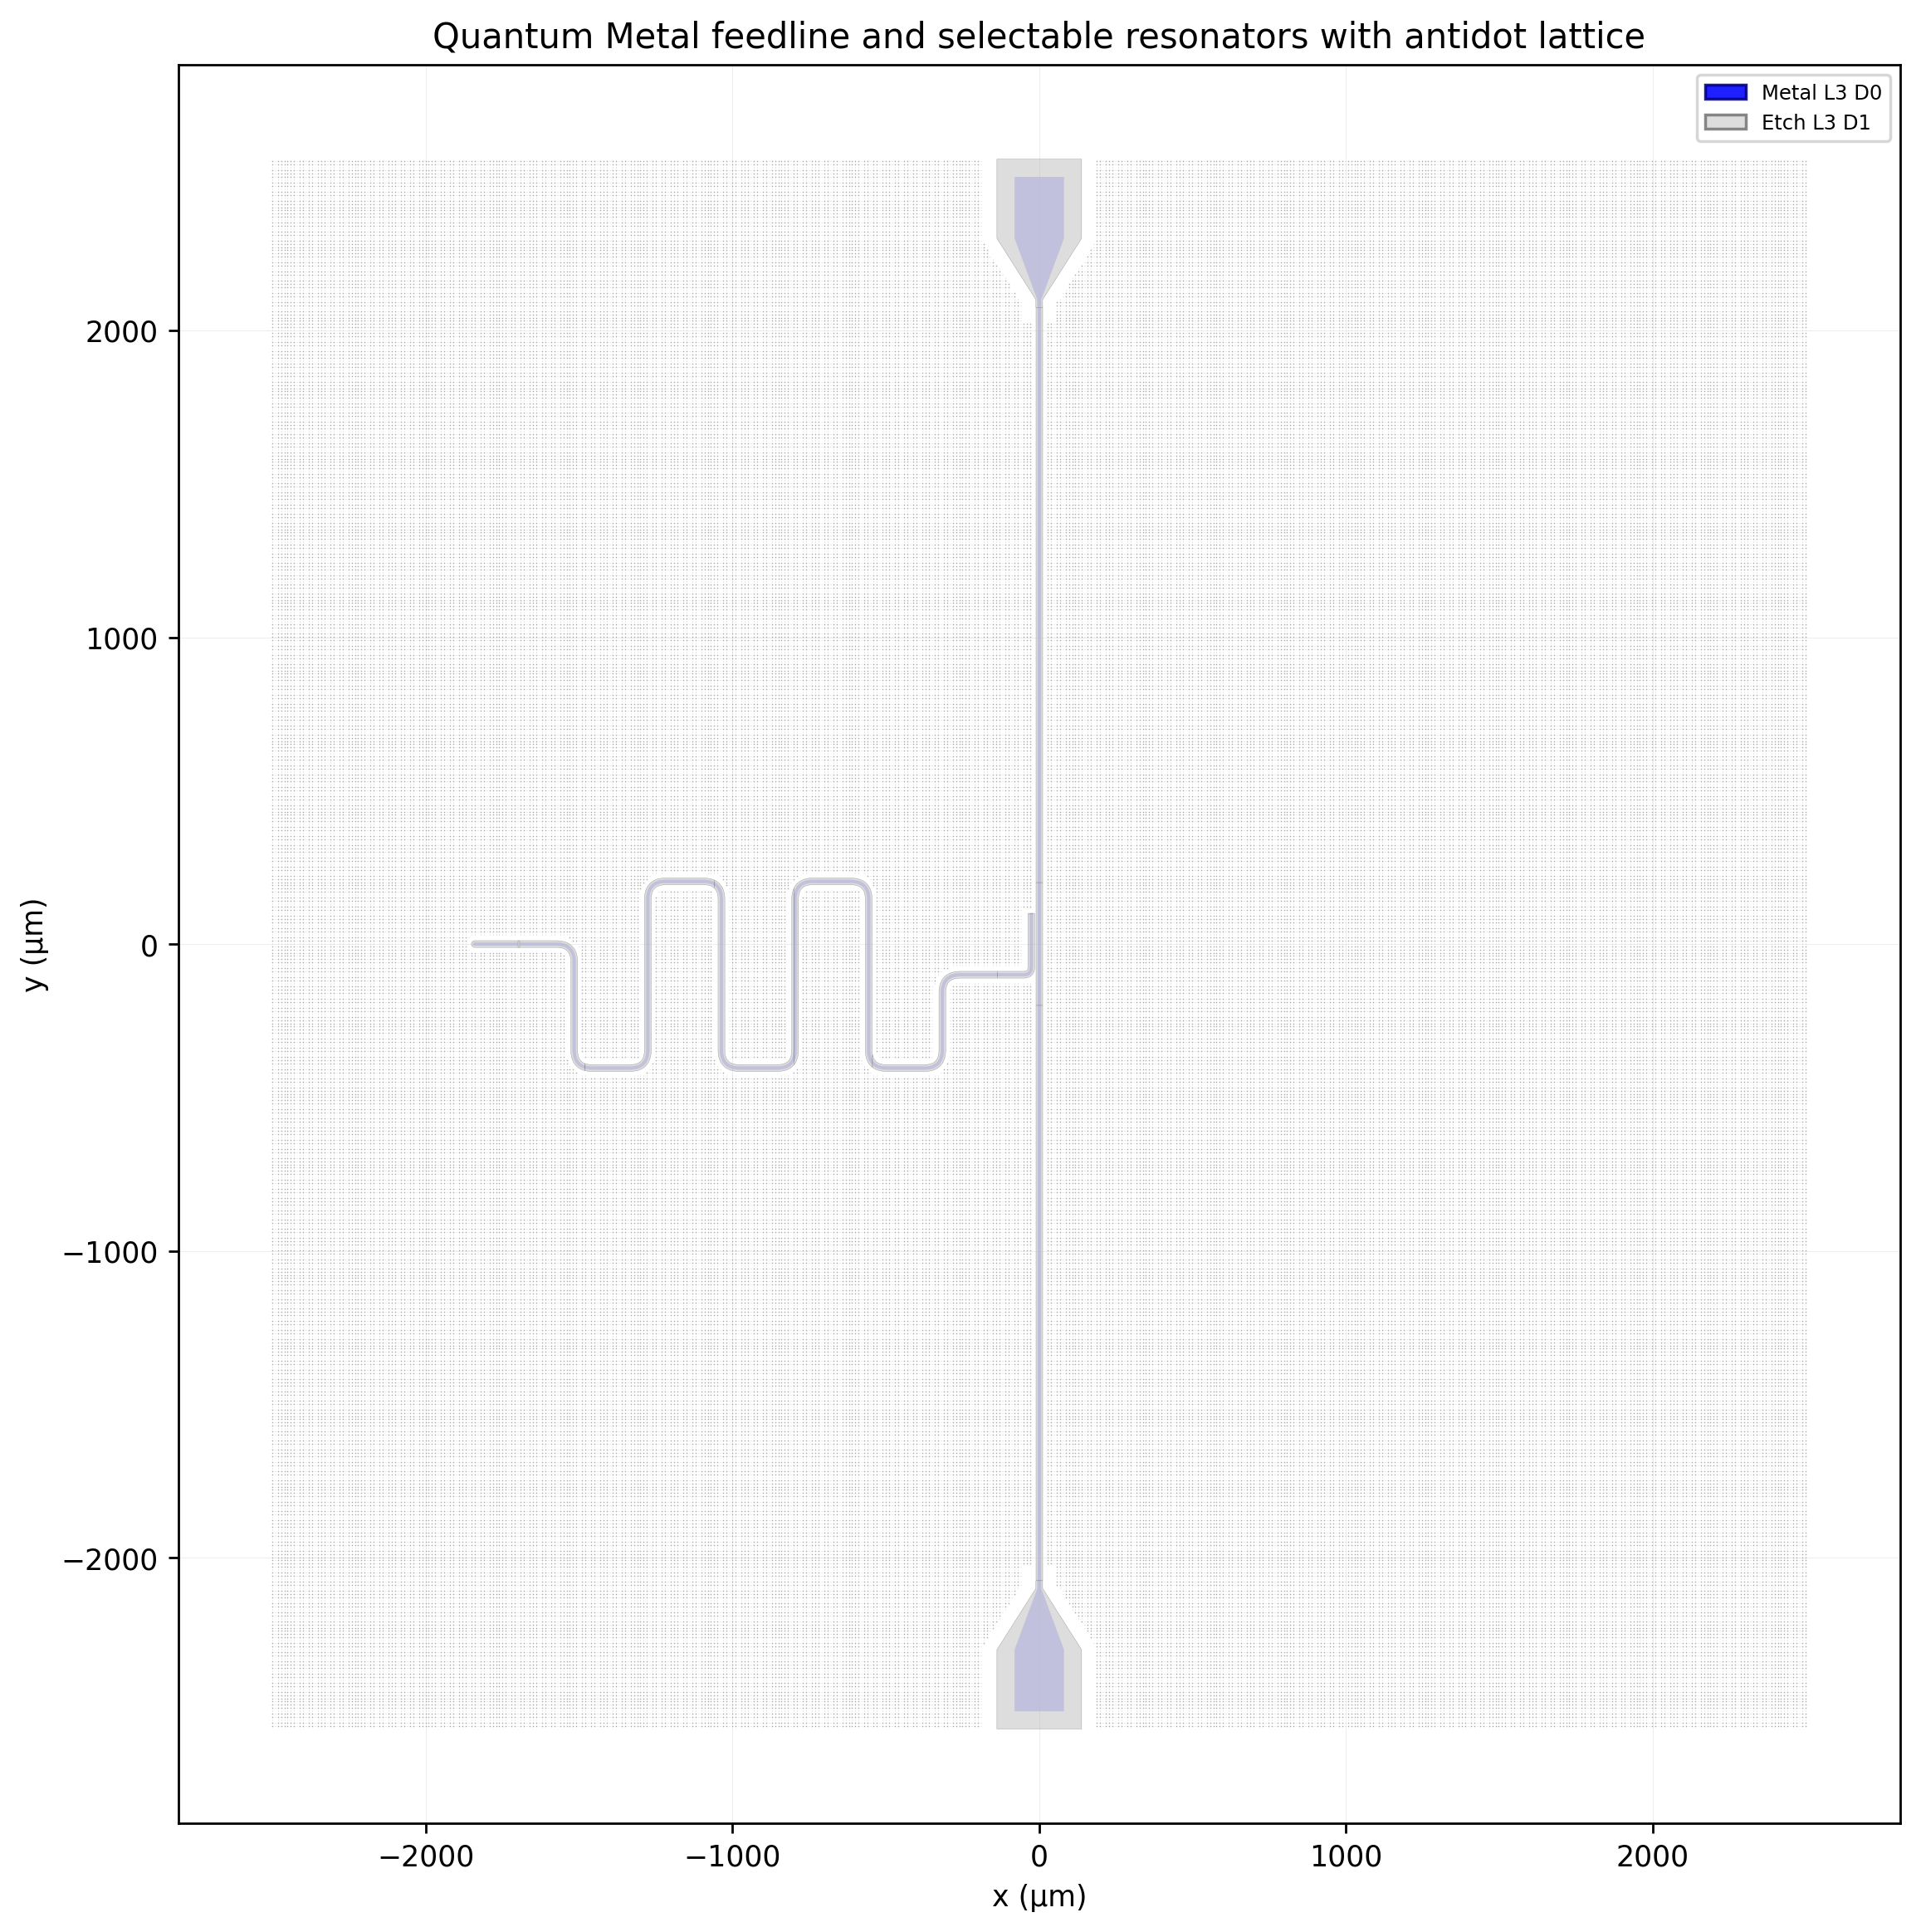

In [2]:
"""Build a selectable Quantum Metal CPW resonator and feedline layout.

The layout contains two wirebond launchers, a connected feedline assembled
around CoupledLineTee components, selectable quarter-wave hanger resonators,
open resonator terminations, and a square antidot lattice. Resonators are
selected only from the ordered target-frequency list, so requesting one
resonator uses the first listed target frequency.
"""

import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Final

warnings.filterwarnings("ignore", category=SyntaxWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import gdstk
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import PatchCollection
from matplotlib.patches import Patch
from matplotlib.patches import Polygon as MplPolygon
from shapely.geometry import GeometryCollection
from shapely.geometry import LineString
from shapely.geometry import MultiLineString
from shapely.geometry import MultiPolygon
from shapely.geometry import Polygon
from shapely.ops import transform

from qiskit_metal import Dict, designs
from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
from qiskit_metal.qlibrary.terminations.launchpad_wb import LaunchpadWirebond
from qiskit_metal.qlibrary.terminations.open_to_ground import OpenToGround
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander
from qiskit_metal.qlibrary.tlines.straight_path import RouteStraight


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------

OUTPUT_GDS_PATH: Final[Path] = Path(
    "/content/resonator_feedline_cheesing_quantum_metal.gds"
)

WRITE_GDS: Final[bool] = True
RENDER_GDS: Final[bool] = True
SHOW_QGEOMETRY_SUMMARY: Final[bool] = True
SHOW_COMPONENT_PIN_AUDIT: Final[bool] = True
SHOW_FILLET_AUDIT: Final[bool] = True

DESIRED_RESONATOR_COUNT: Final[int] = 1
STAGGER_RESONATORS: Final[bool] = True
STAGGER_START_SIDE: Final[str] = "left"
UNSTAGGERED_RESONATOR_SIDE: Final[str] = "left"

TARGET_RESONATOR_FREQUENCIES_GHZ: Final[tuple[float, ...]] = (
    6.116,
    6.353,
    6.472,
    6.568,
    6.655,
    6.704,
)

CPW_PHASE_VELOCITY_M_PER_S: Final[float] = 1.20e8
ACCOUNT_FOR_TEE_CENTERLINE_LENGTH: Final[bool] = True

RESONATOR_ARRAY_CENTER_Y_UM: Final[float] = 0.0
RESONATOR_ARRAY_SPAN_Y_UM: Final[float] = 3000.0
RESONATOR_OPEN_END_X_UM: Final[float] = 1700.0
RESONATOR_MEANDER_ASYMMETRY: Final[str] = "0um"

ENABLE_ANTIDOTS: Final[bool] = True
ANTIDOT_PITCH_UM: Final[float] = 10.0
ANTIDOT_SIZE_UM: Final[float] = 2.0
ANTIDOT_OFFSET_X_UM: Final[float] = 9.0
ANTIDOT_OFFSET_Y_UM: Final[float] = 0.0
ANTIDOT_EXTENSION_Y_UM: Final[float] = 60.0
ANTIDOT_KEEPOUT_UM: Final[float] = 15.0
LAUNCHPAD_KEEPOUT_UM: Final[float] = 45.0

MPL_DPI: Final[int] = 250
FIGURE_WIDTH_IN: Final[float] = 11.0
FIGURE_HEIGHT_IN: Final[float] = 11.0

CHIP_SIZE_X: Final[str] = "5mm"
CHIP_SIZE_Y: Final[str] = "5mm"

COORD_SCALE_TO_UM: Final[float] = 1000.0
GDS_UNIT_M: Final[float] = 1.0e-6
GDS_PRECISION_M: Final[float] = 1.0e-9

METAL_LAYER: Final[int] = 3
SUBTRACT_DATATYPE: Final[int] = 1
NORMAL_DATATYPE: Final[int] = 0

FEEDLINE_TRACE_WIDTH: Final[str] = "11.7um"
FEEDLINE_TRACE_GAP: Final[str] = "5.1um"

ROUTE_TRACE_WIDTH: Final[str] = "10um"
ROUTE_TRACE_GAP: Final[str] = "6um"

RESONATOR_FILLET: Final[str] = "70um"
RESONATOR_MEANDER_SPACING: Final[str] = "240um"
RESONATOR_LEAD_START: Final[str] = "180um"
RESONATOR_LEAD_END: Final[str] = "140um"

DEFAULT_COUPLING_LENGTH: Final[str] = "200um"
DEFAULT_COUPLING_SPACE: Final[str] = "4um"
DEFAULT_DOWN_LENGTH: Final[str] = "110um"
DEFAULT_COUPLER_FILLET: Final[str] = "25um"

DEFAULT_ROUTE_FILLET_UM: Final[float] = 70.0
DEFAULT_COUPLER_FILLET_UM: Final[float] = 25.0
MIN_FILLET_RADIUS_UM: Final[float] = 8.0
FILLET_SAFETY_FRACTION: Final[float] = 0.42
SAMPLES_PER_FILLET: Final[int] = 18
BUFFER_RESOLUTION: Final[int] = 24

LAYER_STYLE_MAP: Final[dict[tuple[int, int], dict[str, str]]] = {
    (3, 0): {"facecolor": "#0000FF", "edgecolor": "#000080", "label": "Metal"},
    (3, 1): {"facecolor": "#D9D9D9", "edgecolor": "#777777", "label": "Etch"},
}

DEFAULT_STYLE: Final[dict[str, str]] = {
    "facecolor": "#A0A0A0",
    "edgecolor": "#505050",
    "label": "Other",
}

mpl.rcParams["font.sans-serif"] = ["Tahoma", "DejaVu Sans"]
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["figure.dpi"] = MPL_DPI

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass


# -----------------------------------------------------------------------------
# Data structures
# -----------------------------------------------------------------------------


@dataclass(frozen=True)
class ResonatorSite:
    """Resolved geometric placement for one resonator."""

    index: int
    name: str
    y_um: float
    side: str
    tee_orientation_deg: int
    open_end_x_um: float
    open_orientation_deg: int


@dataclass(frozen=True)
class ComponentHandles:
    """Created Quantum Metal component references."""

    wirebonds: list[Any]
    tees: list[Any]
    terminations: list[Any]
    resonators: list[Any]
    feedline_segments: list[Any]


# -----------------------------------------------------------------------------
# Selection and numeric helpers
# -----------------------------------------------------------------------------


def normalize_side(side: str) -> str:
    """Normalize a resonator-side control to left or right."""
    normalized = side.strip().lower()

    if normalized in {"left", "right"}:
        return normalized

    raise ValueError(
        f"Resonator side must be 'left' or 'right'; received {side!r}."
    )


def selected_target_frequencies() -> tuple[float, ...]:
    """Select the leading target frequencies allowed by the count knob."""
    if DESIRED_RESONATOR_COUNT < 0:
        raise ValueError("DESIRED_RESONATOR_COUNT must be zero or greater.")

    available_count = len(TARGET_RESONATOR_FREQUENCIES_GHZ)
    selected_count = min(DESIRED_RESONATOR_COUNT, available_count)

    if DESIRED_RESONATOR_COUNT > available_count:
        warnings.warn(
            "Requested resonator count exceeds the target-frequency list; "
            f"building the {available_count} frequency-backed resonators available.",
            RuntimeWarning,
        )

    return TARGET_RESONATOR_FREQUENCIES_GHZ[:selected_count]


def resonator_side_for_index(index: int) -> str:
    """Return the physical feedline side for one resonator index."""
    if STAGGER_RESONATORS:
        first_side = normalize_side(STAGGER_START_SIDE)
        if index % 2 == 0:
            return first_side
        return "right" if first_side == "left" else "left"

    return normalize_side(UNSTAGGERED_RESONATOR_SIDE)


def resonator_y_positions_um(count: int) -> np.ndarray:
    """Return centered resonator y positions spanning the configured array."""
    if count <= 0:
        return np.empty(0, dtype=np.float64)

    if count == 1:
        return np.asarray([RESONATOR_ARRAY_CENTER_Y_UM], dtype=np.float64)

    half_span = 0.5 * RESONATOR_ARRAY_SPAN_Y_UM
    upper = RESONATOR_ARRAY_CENTER_Y_UM + half_span
    lower = RESONATOR_ARRAY_CENTER_Y_UM - half_span
    return np.linspace(upper, lower, count, dtype=np.float64)


def build_resonator_sites(count: int) -> tuple[ResonatorSite, ...]:
    """Build deterministic resonator placements from the control knobs."""
    y_positions = resonator_y_positions_um(count)
    sites: list[ResonatorSite] = []

    for index, y_um in enumerate(y_positions):
        side = resonator_side_for_index(index)
        side_sign = -1.0 if side == "left" else 1.0
        tee_orientation = -90 if side == "left" else 90
        open_orientation = 0 if side == "left" else 180

        sites.append(
            ResonatorSite(
                index=index,
                name=f"R{index + 1:02d}",
                y_um=float(y_um),
                side=side,
                tee_orientation_deg=tee_orientation,
                open_end_x_um=side_sign * abs(RESONATOR_OPEN_END_X_UM),
                open_orientation_deg=open_orientation,
            )
        )

    return tuple(sites)


def quarter_wave_lengths_um(frequencies_ghz: tuple[float, ...]) -> np.ndarray:
    """Compute first-pass quarter-wave electrical lengths in micrometers."""
    frequencies = np.asarray(frequencies_ghz, dtype=np.float64)

    if frequencies.size == 0:
        return np.empty(0, dtype=np.float64)

    lengths_m = CPW_PHASE_VELOCITY_M_PER_S / (4.0 * frequencies * 1.0e9)
    return lengths_m * 1.0e6


def qmetal_value_um(design: Any, value: Any) -> float:
    """Parse a Quantum Metal value and return micrometers."""
    return float(design.parse_value(value)) * COORD_SCALE_TO_UM


def build_resonator_length_plan(
    design: Any,
    frequencies_ghz: tuple[float, ...],
) -> pd.DataFrame:
    """Build nominal electrical lengths and RouteMeander lengths."""
    nominal_lengths_um = quarter_wave_lengths_um(frequencies_ghz)

    fixed_tee_length_um = 0.0
    if ACCOUNT_FOR_TEE_CENTERLINE_LENGTH:
        fixed_tee_length_um = qmetal_value_um(
            design,
            DEFAULT_COUPLING_LENGTH,
        ) + qmetal_value_um(
            design,
            DEFAULT_DOWN_LENGTH,
        )

    route_lengths_um = nominal_lengths_um - fixed_tee_length_um

    if np.any(route_lengths_um <= 0.0):
        raise ValueError(
            "One or more target frequencies produce a nonpositive meander route length."
        )

    return pd.DataFrame(
        {
            "target_frequency_ghz": frequencies_ghz,
            "nominal_lambda4_length_um": nominal_lengths_um,
            "tee_centerline_length_um": fixed_tee_length_um,
            "route_length_um": route_lengths_um,
            "route_total_length": [
                f"{length:.3f}um" for length in route_lengths_um
            ],
        }
    )


# -----------------------------------------------------------------------------
# Quantum Metal build
# -----------------------------------------------------------------------------


def create_design() -> Any:
    """Create a renderer-free planar design."""
    design = designs.DesignPlanar(
        overwrite_enabled=True,
        enable_renderers=False,
    )

    try:
        design.chips.main.size.size_x = CHIP_SIZE_X
        design.chips.main.size.size_y = CHIP_SIZE_Y
    except Exception:
        design._chips["main"]["size"]["size_x"] = CHIP_SIZE_X
        design._chips["main"]["size"]["size_y"] = CHIP_SIZE_Y

    design.variables["cpw_width"] = ROUTE_TRACE_WIDTH
    design.variables["cpw_gap"] = ROUTE_TRACE_GAP
    return design


def select_component_pin(
    component: Any,
    preferred: str,
    fallbacks: tuple[str, ...],
) -> str:
    """Return a valid pin name from a component."""
    pin_names = list(component.pins.keys())

    if preferred in pin_names:
        return preferred

    for candidate in fallbacks:
        if candidate in pin_names:
            return candidate

    raise ValueError(
        f"Could not find a usable pin on {component.name}. "
        f"Available pins are {pin_names}."
    )


def create_wirebond(
    design: Any,
    name: str,
    pos_y: str,
    orientation: str,
) -> Any:
    """Create a feedline wirebond launch pad."""
    return LaunchpadWirebond(
        design,
        name,
        options=Dict(
            pos_x="0um",
            pos_y=pos_y,
            orientation=orientation,
            trace_width=FEEDLINE_TRACE_WIDTH,
            trace_gap=FEEDLINE_TRACE_GAP,
            lead_length="25um",
            pad_width="160um",
            pad_height="200um",
            pad_gap="58um",
            taper_height="200um",
            layer=str(METAL_LAYER),
        ),
    )


def create_coupled_line_tee(
    design: Any,
    site: ResonatorSite,
) -> Any:
    """Create one feedline-side hanger coupler."""
    return CoupledLineTee(
        design,
        f"clt_{site.name}",
        options=Dict(
            pos_x="0um",
            pos_y=f"{site.y_um:.3f}um",
            orientation=str(site.tee_orientation_deg),
            prime_width=FEEDLINE_TRACE_WIDTH,
            prime_gap=FEEDLINE_TRACE_GAP,
            second_width=ROUTE_TRACE_WIDTH,
            second_gap=ROUTE_TRACE_GAP,
            coupling_space=DEFAULT_COUPLING_SPACE,
            coupling_length=DEFAULT_COUPLING_LENGTH,
            down_length=DEFAULT_DOWN_LENGTH,
            fillet=DEFAULT_COUPLER_FILLET,
            mirror=False,
            open_termination=False,
            layer=str(METAL_LAYER),
        ),
    )


def select_tee_output_pin(tee: Any) -> str:
    """Return the hanger-output pin on a coupled-line tee."""
    pin_names = tuple(tee.pins.keys())

    for candidate in ("second_end", "second", "out"):
        if candidate in pin_names:
            return candidate

    for pin_name in pin_names:
        if "second" in pin_name:
            return pin_name

    raise ValueError(
        f"Could not find a tee output pin on {tee.name}. "
        f"Available pins are {list(pin_names)}."
    )


def tee_vertical_pin_names(tee: Any) -> tuple[str, str]:
    """Return the geometrically upper and lower feedline pins of a tee."""
    prime_names = [
        name for name in ("prime_start", "prime_end") if name in tee.pins
    ]

    if len(prime_names) != 2:
        raise ValueError(
            f"Expected two prime pins on {tee.name}; received {prime_names}."
        )

    ordered = sorted(
        prime_names,
        key=lambda name: float(tee.pins[name]["middle"][1]),
        reverse=True,
    )
    return ordered[0], ordered[1]


def create_feedline_route(
    design: Any,
    name: str,
    start_component: Any,
    start_pin: str,
    end_component: Any,
    end_pin: str,
) -> Any:
    """Create one straight feedline section between two free pins."""
    return RouteStraight(
        design,
        name,
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(
                    component=start_component.name,
                    pin=start_pin,
                ),
                end_pin=Dict(
                    component=end_component.name,
                    pin=end_pin,
                ),
            ),
            trace_width=FEEDLINE_TRACE_WIDTH,
            trace_gap=FEEDLINE_TRACE_GAP,
            layer=str(METAL_LAYER),
        ),
    )


def create_segmented_feedline(
    design: Any,
    top_launch: Any,
    bottom_launch: Any,
    tees: list[Any],
) -> list[Any]:
    """Connect launchers and tee primary segments into one vertical feedline."""
    top_launch_pin = select_component_pin(top_launch, "tie", ("in", "out"))
    bottom_launch_pin = select_component_pin(bottom_launch, "tie", ("in", "out"))

    if len(tees) == 0:
        return [
            create_feedline_route(
                design=design,
                name="feedline_01",
                start_component=top_launch,
                start_pin=top_launch_pin,
                end_component=bottom_launch,
                end_pin=bottom_launch_pin,
            )
        ]

    sorted_tees = sorted(
        tees,
        key=lambda tee: max(
            float(tee.pins[pin_name]["middle"][1])
            for pin_name in ("prime_start", "prime_end")
        ),
        reverse=True,
    )

    feedline_segments: list[Any] = []
    route_index = 1

    first_top_pin, _ = tee_vertical_pin_names(sorted_tees[0])
    feedline_segments.append(
        create_feedline_route(
            design=design,
            name=f"feedline_{route_index:02d}",
            start_component=top_launch,
            start_pin=top_launch_pin,
            end_component=sorted_tees[0],
            end_pin=first_top_pin,
        )
    )
    route_index += 1

    for upper_tee, lower_tee in zip(sorted_tees[:-1], sorted_tees[1:]):
        _, upper_bottom_pin = tee_vertical_pin_names(upper_tee)
        lower_top_pin, _ = tee_vertical_pin_names(lower_tee)
        feedline_segments.append(
            create_feedline_route(
                design=design,
                name=f"feedline_{route_index:02d}",
                start_component=upper_tee,
                start_pin=upper_bottom_pin,
                end_component=lower_tee,
                end_pin=lower_top_pin,
            )
        )
        route_index += 1

    _, final_bottom_pin = tee_vertical_pin_names(sorted_tees[-1])
    feedline_segments.append(
        create_feedline_route(
            design=design,
            name=f"feedline_{route_index:02d}",
            start_component=sorted_tees[-1],
            start_pin=final_bottom_pin,
            end_component=bottom_launch,
            end_pin=bottom_launch_pin,
        )
    )

    return feedline_segments


def create_open_termination(
    design: Any,
    site: ResonatorSite,
) -> Any:
    """Create the open termination that replaces the former qubit endpoint."""
    return OpenToGround(
        design,
        f"open_{site.name}",
        options=Dict(
            pos_x=f"{site.open_end_x_um:.3f}um",
            pos_y=f"{site.y_um:.3f}um",
            orientation=str(site.open_orientation_deg),
            width=ROUTE_TRACE_WIDTH,
            gap=ROUTE_TRACE_GAP,
            termination_gap=ROUTE_TRACE_GAP,
            layer=str(METAL_LAYER),
        ),
    )


def create_resonator(
    design: Any,
    site: ResonatorSite,
    tee: Any,
    termination: Any,
    total_length: str,
) -> Any:
    """Create one quarter-wave meander between a tee and open endpoint."""
    tee_pin = select_tee_output_pin(tee)
    termination_pin = select_component_pin(
        termination,
        "open",
        tuple(termination.pins.keys()),
    )

    return RouteMeander(
        design,
        f"rr_{site.name}",
        options=Dict(
            pin_inputs=Dict(
                start_pin=Dict(component=tee.name, pin=tee_pin),
                end_pin=Dict(
                    component=termination.name,
                    pin=termination_pin,
                ),
            ),
            lead=Dict(
                start_straight=RESONATOR_LEAD_START,
                end_straight=RESONATOR_LEAD_END,
            ),
            fillet=RESONATOR_FILLET,
            total_length=total_length,
            trace_width=ROUTE_TRACE_WIDTH,
            trace_gap=ROUTE_TRACE_GAP,
            meander=Dict(
                spacing=RESONATOR_MEANDER_SPACING,
                asymmetry=RESONATOR_MEANDER_ASYMMETRY,
            ),
            prevent_short_edges="true",
            snap="true",
            layer=str(METAL_LAYER),
        ),
    )


def build_chip() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build the feedline and the frequency-backed resonator selection."""
    design = create_design()
    frequencies = selected_target_frequencies()
    sites = build_resonator_sites(len(frequencies))
    length_plan = build_resonator_length_plan(design, frequencies)

    top_launch = create_wirebond(
        design=design,
        name="wb_top",
        pos_y="2100um",
        orientation="-90",
    )
    bottom_launch = create_wirebond(
        design=design,
        name="wb_bottom",
        pos_y="-2100um",
        orientation="90",
    )

    tees = [create_coupled_line_tee(design, site) for site in sites]
    feedline_segments = create_segmented_feedline(
        design=design,
        top_launch=top_launch,
        bottom_launch=bottom_launch,
        tees=tees,
    )

    terminations: list[Any] = []
    resonators: list[Any] = []
    summary_records: list[dict[str, Any]] = []

    for site, tee, length_row in zip(
        sites,
        tees,
        length_plan.to_dict(orient="records"),
    ):
        termination = create_open_termination(design, site)
        resonator = create_resonator(
            design=design,
            site=site,
            tee=tee,
            termination=termination,
            total_length=str(length_row["route_total_length"]),
        )

        terminations.append(termination)
        resonators.append(resonator)

        summary_records.append(
            {
                "resonator": site.name,
                "side": site.side,
                "y_um": site.y_um,
                "target_frequency_ghz": length_row["target_frequency_ghz"],
                "nominal_lambda4_length_um": length_row[
                    "nominal_lambda4_length_um"
                ],
                "tee_centerline_length_um": length_row[
                    "tee_centerline_length_um"
                ],
                "route_total_length": length_row["route_total_length"],
                "tee_orientation_deg": site.tee_orientation_deg,
                "open_end_x_um": site.open_end_x_um,
                "staggered": STAGGER_RESONATORS,
            }
        )

    handles = ComponentHandles(
        wirebonds=[top_launch, bottom_launch],
        tees=tees,
        terminations=terminations,
        resonators=resonators,
        feedline_segments=feedline_segments,
    )
    summary = pd.DataFrame(summary_records)

    return design, handles, summary


# -----------------------------------------------------------------------------
# Direct qgeometry to filleted GDSTK export
# -----------------------------------------------------------------------------


def parse_bool(value: Any) -> bool:
    """Parse a possible bool-like qgeometry value."""
    if isinstance(value, bool):
        return value

    if isinstance(value, str):
        return value.strip().lower() in {"true", "1", "yes"}

    try:
        return bool(value)
    except Exception:
        return False


def parse_layer(value: Any, fallback: int = METAL_LAYER) -> int:
    """Parse a qgeometry layer value."""
    try:
        if pd.isna(value):
            return fallback
    except Exception:
        pass

    try:
        return int(value)
    except Exception:
        return fallback


def parse_value_mm(
    design: Any,
    value: Any,
    fallback_mm: float,
) -> float:
    """Parse a Quantum Metal value into millimeters."""
    if value is None:
        return fallback_mm

    try:
        if pd.isna(value):
            return fallback_mm
    except Exception:
        pass

    try:
        return float(design.parse_value(value))
    except Exception:
        pass

    try:
        return float(value)
    except Exception:
        return fallback_mm


def parse_value_um(
    design: Any,
    value: Any,
    fallback_um: float,
) -> float:
    """Parse a Quantum Metal value into micrometers."""
    value_mm = parse_value_mm(
        design=design,
        value=value,
        fallback_mm=fallback_um / COORD_SCALE_TO_UM,
    )
    return value_mm * COORD_SCALE_TO_UM


def component_lookup_by_id(design: Any) -> dict[int, Any]:
    """Map Quantum Metal component IDs to component objects."""
    lookup: dict[int, Any] = {}

    for component in design.components.values():
        component_id = getattr(component, "id", None)

        if component_id is None:
            component_id = getattr(component, "_id", None)

        if component_id is None:
            continue

        try:
            lookup[int(component_id)] = component
        except Exception:
            continue

    return lookup


def component_for_row(
    design: Any,
    row: pd.Series,
    lookup: dict[int, Any],
) -> Any | None:
    """Return the component associated with a qgeometry row."""
    component_value = row.get("component")

    try:
        return lookup.get(int(component_value))
    except Exception:
        pass

    if isinstance(component_value, str):
        try:
            return design.components[component_value]
        except Exception:
            return None

    return None


def get_option(component: Any | None, key: str) -> Any | None:
    """Read a component option if present."""
    if component is None:
        return None

    options = getattr(component, "options", None)
    if options is None:
        return None

    try:
        return options[key]
    except Exception:
        pass

    try:
        return options.get(key)
    except Exception:
        return None


def trace_width_um(
    design: Any,
    row: pd.Series,
    component: Any | None,
) -> float:
    """Return the trace width for a LineString row."""
    row_width = row.get("width")

    if row_width is None:
        for key in ("trace_width", "second_width", "prime_width", "width"):
            value = get_option(component, key)
            if value is None:
                continue
            return parse_value_um(
                design=design,
                value=value,
                fallback_um=10.0,
            )
        return 10.0

    return parse_value_um(
        design=design,
        value=row_width,
        fallback_um=10.0,
    )


def requested_fillet_um(
    design: Any,
    component: Any | None,
) -> float:
    """Return the intended microwave-route fillet in micrometers."""
    class_name = "" if component is None else component.__class__.__name__
    option_value = get_option(component, "fillet")

    if option_value is None:
        if "Route" in class_name:
            return DEFAULT_ROUTE_FILLET_UM
        if "CoupledLineTee" in class_name:
            return DEFAULT_COUPLER_FILLET_UM
        return 0.0

    return parse_value_um(
        design=design,
        value=option_value,
        fallback_um=DEFAULT_ROUTE_FILLET_UM,
    )


def scale_geometry_to_um(geometry: Any) -> Any:
    """Scale Shapely geometry from millimeters to micrometers."""
    return transform(
        lambda x_coord, y_coord, z_coord=None: (
            x_coord * COORD_SCALE_TO_UM,
            y_coord * COORD_SCALE_TO_UM,
        ),
        geometry,
    )


def clean_coords(coords: Any) -> np.ndarray:
    """Return polygon coordinates without duplicated closure."""
    points = np.asarray(coords, dtype=float)

    if len(points) >= 2 and np.allclose(points[0], points[-1]):
        points = points[:-1]

    return points


def clean_line_points(points: np.ndarray) -> np.ndarray:
    """Remove repeated consecutive centerline points."""
    cleaned: list[np.ndarray] = []

    for point in np.asarray(points, dtype=float):
        if len(cleaned) == 0:
            cleaned.append(point)
            continue

        if np.linalg.norm(point - cleaned[-1]) > 1.0e-9:
            cleaned.append(point)

    return np.asarray(cleaned, dtype=float)


def quadratic_bezier_points(
    start: np.ndarray,
    control: np.ndarray,
    end: np.ndarray,
    samples: int,
) -> np.ndarray:
    """Sample a quadratic Bezier fillet segment."""
    t_values = np.linspace(0.0, 1.0, samples + 2)
    return (
        ((1.0 - t_values) ** 2)[:, None] * start[None, :]
        + (2.0 * (1.0 - t_values) * t_values)[:, None] * control[None, :]
        + (t_values**2)[:, None] * end[None, :]
    )


def safe_corner_radius_um(
    points: np.ndarray,
    requested_radius_um: float,
) -> float:
    """Clamp the requested fillet radius to available segment lengths."""
    if points.shape[0] < 3 or requested_radius_um <= 0.0:
        return 0.0

    segment_lengths = np.linalg.norm(np.diff(points, axis=0), axis=1)
    if segment_lengths.shape[0] < 2:
        return 0.0

    adjacent_limits = [
        min(segment_lengths[index - 1], segment_lengths[index])
        for index in range(1, points.shape[0] - 1)
    ]

    if len(adjacent_limits) == 0:
        return 0.0

    allowed_radius = FILLET_SAFETY_FRACTION * min(adjacent_limits)
    radius = min(float(requested_radius_um), float(allowed_radius))

    if radius < MIN_FILLET_RADIUS_UM:
        return 0.0

    return radius


def rounded_centerline_um(
    line: LineString,
    requested_radius_um: float,
) -> tuple[np.ndarray, float]:
    """Return a rounded centerline sampled in micrometers and its radius."""
    raw_points = np.asarray(line.coords, dtype=float) * COORD_SCALE_TO_UM
    points = clean_line_points(raw_points)

    if points.shape[0] <= 2:
        return points, 0.0

    radius_um = safe_corner_radius_um(points, requested_radius_um)

    if radius_um <= 0.0:
        return points, 0.0

    output: list[np.ndarray] = [points[0]]

    for index in range(1, points.shape[0] - 1):
        previous_point = points[index - 1]
        corner_point = points[index]
        next_point = points[index + 1]

        incoming = corner_point - previous_point
        outgoing = next_point - corner_point

        incoming_length = float(np.linalg.norm(incoming))
        outgoing_length = float(np.linalg.norm(outgoing))

        if incoming_length <= 1.0e-12 or outgoing_length <= 1.0e-12:
            continue

        incoming_unit = incoming / incoming_length
        outgoing_unit = outgoing / outgoing_length

        cosine_angle = float(
            np.clip(np.dot(incoming_unit, outgoing_unit), -1.0, 1.0)
        )
        deflection = math.acos(cosine_angle)

        if deflection <= 1.0e-9 or abs(math.pi - deflection) <= 1.0e-9:
            output.append(corner_point)
            continue

        trim_um = radius_um * math.tan(0.5 * deflection)
        trim_um = min(
            trim_um,
            0.45 * incoming_length,
            0.45 * outgoing_length,
        )

        entry_point = corner_point - incoming_unit * trim_um
        exit_point = corner_point + outgoing_unit * trim_um

        if np.linalg.norm(output[-1] - entry_point) > 1.0e-9:
            output.append(entry_point)

        curve = quadratic_bezier_points(
            start=entry_point,
            control=corner_point,
            end=exit_point,
            samples=SAMPLES_PER_FILLET,
        )

        for curve_point in curve[1:]:
            output.append(curve_point)

    if np.linalg.norm(output[-1] - points[-1]) > 1.0e-9:
        output.append(points[-1])

    return np.asarray(output, dtype=float), radius_um


def line_to_rounded_polygon(
    line: LineString,
    width_um: float,
    requested_radius_um: float,
) -> tuple[Polygon, float]:
    """Convert a centerline into a rounded CPW trace polygon."""
    centerline, used_radius_um = rounded_centerline_um(
        line=line,
        requested_radius_um=requested_radius_um,
    )

    if centerline.shape[0] < 2:
        return Polygon(), used_radius_um

    trace = LineString(centerline).buffer(
        0.5 * width_um,
        cap_style=2,
        join_style=1,
        resolution=BUFFER_RESOLUTION,
    )
    return trace, used_radius_um


def polygon_to_gdstk(
    polygon: Polygon,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert a Shapely polygon, including holes, into GDSTK polygons."""
    if polygon.is_empty or polygon.area <= 0.0:
        return []

    outer = gdstk.Polygon(
        clean_coords(polygon.exterior.coords),
        layer=layer,
        datatype=datatype,
    )

    holes = [
        gdstk.Polygon(
            clean_coords(interior.coords),
            layer=layer,
            datatype=datatype,
        )
        for interior in polygon.interiors
    ]

    if len(holes) == 0:
        return [outer]

    return gdstk.boolean(
        [outer],
        holes,
        "not",
        precision=1.0e-3,
        layer=layer,
        datatype=datatype,
    )


def geometry_to_gdstk(
    geometry: Any,
    layer: int,
    datatype: int,
) -> list[gdstk.Polygon]:
    """Convert Shapely polygonal geometry into GDSTK polygons."""
    if geometry.is_empty:
        return []

    if isinstance(geometry, Polygon):
        return polygon_to_gdstk(geometry, layer, datatype)

    if isinstance(geometry, MultiPolygon):
        polygons: list[gdstk.Polygon] = []
        for polygon in geometry.geoms:
            polygons.extend(polygon_to_gdstk(polygon, layer, datatype))
        return polygons

    if isinstance(geometry, GeometryCollection):
        polygons: list[gdstk.Polygon] = []
        for item in geometry.geoms:
            polygons.extend(geometry_to_gdstk(item, layer, datatype))
        return polygons

    return []


def row_geometry_to_polygons(
    design: Any,
    table_name: str,
    row: pd.Series,
    lookup: dict[int, Any],
    fillet_records: list[dict[str, Any]],
) -> list[gdstk.Polygon]:
    """Convert one qgeometry row to one or more GDSTK polygons."""
    geometry = row.get("geometry")

    if geometry is None or geometry.is_empty:
        return []

    component = component_for_row(design, row, lookup)
    component_name = "unknown" if component is None else component.name
    component_class = (
        "unknown" if component is None else component.__class__.__name__
    )

    layer = parse_layer(row.get("layer"), fallback=METAL_LAYER)
    subtract = parse_bool(row.get("subtract", False))
    datatype = SUBTRACT_DATATYPE if subtract else NORMAL_DATATYPE

    if isinstance(geometry, LineString):
        width_um = trace_width_um(design, row, component)
        fillet_um = requested_fillet_um(design, component)
        rounded_geometry, used_radius = line_to_rounded_polygon(
            line=geometry,
            width_um=width_um,
            requested_radius_um=fillet_um,
        )

        fillet_records.append(
            {
                "table": table_name,
                "component": component_name,
                "class": component_class,
                "width_um": width_um,
                "requested_fillet_um": fillet_um,
                "used_fillet_um": used_radius,
            }
        )

        return geometry_to_gdstk(rounded_geometry, layer, datatype)

    if isinstance(geometry, MultiLineString):
        width_um = trace_width_um(design, row, component)
        fillet_um = requested_fillet_um(design, component)
        polygons: list[gdstk.Polygon] = []

        for line in geometry.geoms:
            rounded_geometry, used_radius = line_to_rounded_polygon(
                line=line,
                width_um=width_um,
                requested_radius_um=fillet_um,
            )
            polygons.extend(
                geometry_to_gdstk(rounded_geometry, layer, datatype)
            )

            fillet_records.append(
                {
                    "table": table_name,
                    "component": component_name,
                    "class": component_class,
                    "width_um": width_um,
                    "requested_fillet_um": fillet_um,
                    "used_fillet_um": used_radius,
                }
            )

        return polygons

    scaled_geometry = scale_geometry_to_um(geometry)
    return geometry_to_gdstk(scaled_geometry, layer, datatype)


def export_qgeometry_to_gds(
    design: Any,
    output_path: Path,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Export qgeometry with reconstructed fillets and square antidots."""
    library = gdstk.Library(unit=GDS_UNIT_M, precision=GDS_PRECISION_M)
    top_cell = library.new_cell("TOP")

    all_polygons: list[gdstk.Polygon] = []
    export_records: list[dict[str, Any]] = []
    fillet_records: list[dict[str, Any]] = []
    lookup = component_lookup_by_id(design)

    cut_polygons_default: list[gdstk.Polygon] = []
    cut_polygons_launcher: list[gdstk.Polygon] = []

    for table_name, table in design.qgeometry.tables.items():
        if table is None or table.empty:
            continue

        for _, row in table.iterrows():
            component = component_for_row(design, row, lookup)
            component_class = (
                "unknown"
                if component is None
                else component.__class__.__name__
            )

            polygons = row_geometry_to_polygons(
                design=design,
                table_name=table_name,
                row=row,
                lookup=lookup,
                fillet_records=fillet_records,
            )
            all_polygons.extend(polygons)

            for polygon in polygons:
                if polygon.datatype == SUBTRACT_DATATYPE:
                    if component_class == "LaunchpadWirebond":
                        cut_polygons_launcher.append(polygon)
                    else:
                        cut_polygons_default.append(polygon)

    if ENABLE_ANTIDOTS:
        chip_width = float(CHIP_SIZE_X.replace("mm", "")) * 1000.0
        chip_height = float(CHIP_SIZE_Y.replace("mm", "")) * 1000.0

        keep_out_region: list[gdstk.Polygon] = []

        if len(cut_polygons_default) > 0:
            keep_out_default = gdstk.offset(
                cut_polygons_default,
                ANTIDOT_KEEPOUT_UM,
                precision=1.0e-3,
            )
            keep_out_region.extend(keep_out_default)

        if len(cut_polygons_launcher) > 0:
            keep_out_launcher = gdstk.offset(
                cut_polygons_launcher,
                LAUNCHPAD_KEEPOUT_UM,
                precision=1.0e-3,
            )
            keep_out_region.extend(keep_out_launcher)

        x_positive = np.arange(
            ANTIDOT_OFFSET_X_UM,
            chip_width / 2.0,
            ANTIDOT_PITCH_UM,
        )
        x_coordinates = np.unique(np.concatenate((-x_positive, x_positive)))

        y_limit = (chip_height / 2.0) + ANTIDOT_EXTENSION_Y_UM
        y_positive = np.arange(
            ANTIDOT_OFFSET_Y_UM,
            y_limit,
            ANTIDOT_PITCH_UM,
        )
        y_coordinates = np.unique(np.concatenate((-y_positive, y_positive)))

        grid_points = [
            (float(x_coord), float(y_coord))
            for x_coord in x_coordinates
            for y_coord in y_coordinates
        ]
        inside_flags = gdstk.inside(grid_points, keep_out_region)

        filtered_antidots: list[gdstk.Polygon] = []
        half_size = ANTIDOT_SIZE_UM / 2.0

        for point, inside_flag in zip(grid_points, inside_flags):
            if bool(inside_flag) is False:
                filtered_antidots.append(
                    gdstk.rectangle(
                        (point[0] - half_size, point[1] - half_size),
                        (point[0] + half_size, point[1] + half_size),
                        layer=METAL_LAYER,
                        datatype=SUBTRACT_DATATYPE,
                    )
                )

        all_polygons.extend(filtered_antidots)

    for polygon in all_polygons:
        export_records.append(
            {
                "layer": int(polygon.layer),
                "datatype": int(polygon.datatype),
                "vertices": int(len(polygon.points)),
                "area_um2": float(abs(polygon.area())),
            }
        )

    if len(all_polygons) == 0:
        raise RuntimeError("No qgeometry polygons were produced for GDSTK export.")

    top_cell.add(*all_polygons)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if WRITE_GDS:
        library.write_gds(str(output_path))

    return pd.DataFrame(export_records), pd.DataFrame(fillet_records)


# -----------------------------------------------------------------------------
# Audit and render
# -----------------------------------------------------------------------------


def audit_component_pins(design: Any) -> pd.DataFrame:
    """Return a table of component names and pin names."""
    records: list[dict[str, str]] = []

    for name, component in design.components.items():
        records.append(
            {
                "component": name,
                "class": component.__class__.__name__,
                "pins": ",".join(component.pins.keys()),
            }
        )

    return pd.DataFrame(records).sort_values("component").reset_index(drop=True)


def summarize_export(export_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize the direct GDSTK export by layer and datatype."""
    return (
        export_table.groupby(["layer", "datatype"], as_index=False)
        .agg(
            polygon_count=("area_um2", "size"),
            total_area_um2=("area_um2", "sum"),
            min_vertices=("vertices", "min"),
            max_vertices=("vertices", "max"),
        )
        .sort_values(["layer", "datatype"])
        .reset_index(drop=True)
    )


def summarize_fillets(fillet_table: pd.DataFrame) -> pd.DataFrame:
    """Summarize requested and used fillet radii by component class."""
    if fillet_table.empty:
        return pd.DataFrame()

    return (
        fillet_table.groupby(["class"], as_index=False)
        .agg(
            line_count=("used_fillet_um", "size"),
            width_min_um=("width_um", "min"),
            width_max_um=("width_um", "max"),
            requested_fillet_max_um=("requested_fillet_um", "max"),
            used_fillet_min_um=("used_fillet_um", "min"),
            used_fillet_max_um=("used_fillet_um", "max"),
        )
        .sort_values("class")
        .reset_index(drop=True)
    )


def load_exported_polygons(gds_path: Path) -> list[gdstk.Polygon]:
    """Load polygons from the exported GDS."""
    library = gdstk.read_gds(str(gds_path))
    top_cells = library.top_level()

    if len(top_cells) == 0:
        raise RuntimeError("The exported GDS has no top-level cells.")

    return top_cells[0].get_polygons(depth=None)


def style_for_polygon(polygon: gdstk.Polygon) -> dict[str, str]:
    """Return style for a GDSTK polygon."""
    return LAYER_STYLE_MAP.get(
        (int(polygon.layer), int(polygon.datatype)),
        DEFAULT_STYLE,
    )


def render_exported_gds(gds_path: Path) -> None:
    """Render the exported GDS directly in the notebook environment."""
    polygons = load_exported_polygons(gds_path)

    if len(polygons) == 0:
        raise RuntimeError("No polygons were found in the exported GDS.")

    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH_IN, FIGURE_HEIGHT_IN))
    legend_entries: dict[tuple[int, int], Patch] = {}

    keys = sorted(
        {(int(poly.layer), int(poly.datatype)) for poly in polygons}
    )

    for key in keys:
        key_polygons = [
            poly
            for poly in polygons
            if (int(poly.layer), int(poly.datatype)) == key
        ]
        style = style_for_polygon(key_polygons[0])

        patches = [
            MplPolygon(np.asarray(poly.points), closed=True)
            for poly in key_polygons
        ]

        collection = PatchCollection(
            patches,
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            linewidth=0.10,
            alpha=0.88,
        )
        ax.add_collection(collection)

        legend_entries[key] = Patch(
            facecolor=style["facecolor"],
            edgecolor=style["edgecolor"],
            label=f'{style["label"]} L{key[0]} D{key[1]}',
            alpha=0.88,
        )

    all_points = np.vstack([np.asarray(poly.points) for poly in polygons])
    x_min = float(np.min(all_points[:, 0]))
    x_max = float(np.max(all_points[:, 0]))
    y_min = float(np.min(all_points[:, 1]))
    y_max = float(np.max(all_points[:, 1]))

    span = max(x_max - x_min, y_max - y_min)
    margin = 0.06 * span

    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(
        "Quantum Metal feedline and selectable resonators with antidot lattice"
    )
    ax.grid(True, linewidth=0.25, alpha=0.25)
    ax.legend(
        handles=list(legend_entries.values()),
        fontsize=7,
        loc="upper right",
    )

    plt.show()


# -----------------------------------------------------------------------------
# Main execution
# -----------------------------------------------------------------------------


def main() -> tuple[Any, ComponentHandles, pd.DataFrame]:
    """Build the layout, export qgeometry, and render the GDS."""
    selected_frequencies = selected_target_frequencies()

    print("Creating DesignPlanar with enable_renderers=False.")
    print(
        "Requested resonators: "
        f"{DESIRED_RESONATOR_COUNT}; frequency-backed resonators: "
        f"{len(selected_frequencies)}."
    )
    print(f"Selected target frequencies (GHz): {selected_frequencies}")
    print(f"Stagger resonators: {STAGGER_RESONATORS}")

    design, handles, summary = build_chip()

    print("\nResonator and feedline plan")
    display(summary)

    if SHOW_COMPONENT_PIN_AUDIT:
        print("\nComponent pin audit")
        display(audit_component_pins(design))

    export_table, fillet_table = export_qgeometry_to_gds(
        design=design,
        output_path=OUTPUT_GDS_PATH,
    )

    if WRITE_GDS:
        print(f"\nWrote GDSTK GDS: {OUTPUT_GDS_PATH}")

    if SHOW_QGEOMETRY_SUMMARY:
        print("\nDirect export summary")
        display(
            summarize_export(export_table).style.format(
                {"total_area_um2": "{:.6e}"}
            )
        )

    if SHOW_FILLET_AUDIT:
        print("\nFillet audit")
        display(
            summarize_fillets(fillet_table).style.format(
                {
                    "width_min_um": "{:.3f}",
                    "width_max_um": "{:.3f}",
                    "requested_fillet_max_um": "{:.3f}",
                    "used_fillet_min_um": "{:.3f}",
                    "used_fillet_max_um": "{:.3f}",
                }
            )
        )

    if RENDER_GDS:
        if WRITE_GDS is False:
            raise RuntimeError(
                "RENDER_GDS requires WRITE_GDS=True for file-based rendering."
            )
        render_exported_gds(OUTPUT_GDS_PATH)

    return design, handles, summary


design, component_handles, resonator_plan = main()

In [3]:
!apt-get -qq update && apt-get -qq install -y openmpi-bin libopenmpi-dev
!pip install -q "k3d==2.18.1" trimesh "cupy-cuda12x>=13.0,<14" ipywidgets

# Enable Colab widget support.
from google.colab import output
output.enable_custom_widget_manager()

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
